#프로젝트 : mini BERT 만들기
- > vocab size를 8000으로 줄이고, 전체 파라미터 사이즈가 1M 정도가 되는 아주 작은 mini BERT 모델을 만들어 10 Epoch까지 학습시킨 모델을 만들어 보는 것입니다.

In [13]:
import torch
import numpy
import pandas
import matplotlib
import json
import re

print(torch.__version__)
print(numpy.__version__)
print(pandas.__version__)
print(matplotlib.__version__)
print(json.__version__)
print(re.__version__)

2.10.0+cu128
2.0.2
2.2.2
3.10.0
2.0.9
2.2.1


##라이브러리 로드 및 하이퍼파라미터 설정
가장 먼저 필요한 라이브러리들을 불러오고, 파라미터 수가 약 100만 개(1M)가 되도록 미니 BERT의 뼈대를 설정합니다.

In [14]:
import math
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# ==========================================
# 1. 미니 BERT 하이퍼파라미터 설정 (~1M 파라미터 타겟)
# ==========================================
class Config:
    vocab_size = 8000   # (평가기준) 8000으로 축소된 단어장 사이즈
    d_model = 128       # 임베딩 및 은닉층 차원 (128)
    n_layers = 2        # 트랜스포머 인코더 층 수 (2개)
    n_heads = 4         # 멀티 헤드 어텐션의 헤드 수 (128 / 4 = 32 차원씩 나누어 가짐)
    d_ff = 512          # 피드포워드 신경망의 내부 차원 (통상 d_model의 4배)
    max_len = 256       # 입력될 최대 문장 길이
    n_segments = 2      # 문장 A, B를 구분하기 위한 세그먼트 수
    dropout = 0.1       # 과적합 방지용 드롭아웃 비율
    batch_size = 64     # 한 번에 학습할 데이터 묶음 크기
    epochs = 10         # (평가기준) 총 10회 학습 반복
    lr = 5e-4           # 학습률 (모델이 작으므로 약간 크게 설정)

config = Config()
# GPU 사용 가능 여부 확인 (Colab 환경에서는 'cuda'로 설정됨)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 설정된 디바이스: {device}")

현재 설정된 디바이스: cuda


###데이터 전처리 함수 정의 (MLM & NSP)
 BERT의 사전학습을 위한 두 가지 목표인 마스크 언어 모델(MLM)과 다음 문장 예측(NSP) 데이터를 생성하는 헬퍼 함수들입니다.


In [2]:
# ==========================================
# 2. 데이터 전처리 (MLM 및 NSP 인스턴스 생성)
# ==========================================

def truncate_seq_pair(tokens_a, tokens_b, max_num_tokens):
    """두 문장의 합친 길이가 최대 길이를 넘지 않도록 긴 쪽의 단어를 하나씩 잘라냅니다."""
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_num_tokens:
            break
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop()
        else:
            tokens_b.pop()

def create_pretrain_mask(tokens, mask_prob, vocab_list):
    """15% 확률로 토큰을 마스킹합니다 (80%는 [MASK], 10%는 랜덤, 10%는 원본 유지)."""
    output_tokens = list(tokens)
    masked_pos = []
    masked_labels = []

    for i, token in enumerate(tokens):
        # 특수 토큰은 마스킹하지 않음
        if token in ['[CLS]', '[SEP]', '[PAD]', '[MASK]']:
            continue

        # 15% 확률로 마스킹 대상 선정
        if random.random() < mask_prob:
            prob = random.random()
            if prob < 0.8:
                output_tokens[i] = '[MASK]'                 # 80% 확률로 [MASK]
            elif prob < 0.9:
                output_tokens[i] = random.choice(vocab_list) # 10% 확률로 랜덤 단어

            masked_pos.append(i)          # 마스킹된 위치 저장
            masked_labels.append(token)   # 원래 정답 단어 저장

    return output_tokens, masked_pos, masked_labels

def create_pretrain_instances(docs, vocab, max_seq_length, mask_prob=0.15):
    """(제출용 핵심 로직) 문장들을 모아 NSP와 MLM 정답이 포함된 데이터셋을 생성합니다."""
    instances = []
    vocab_list = [vocab.id_to_piece(i) for i in range(vocab.get_piece_size())]

    for i in range(len(docs)):
        doc = docs[i]
        for j in range(len(doc)):
            # 매 줄마다 새롭게 토큰화를 수행합니다.
            tokens_a = vocab.encode_as_pieces(doc[j])
            tokens_b = []

            # --- NSP (Next Sentence Prediction) ---
            # 50% 확률로 실제 이어지는 다음 문장을 선택
            if len(doc) > j + 1 and random.random() < 0.5:
                is_next = 1
                tokens_b = vocab.encode_as_pieces(doc[j + 1])
            # 50% 확률로 다른 문서의 랜덤한 문장을 선택
            else:
                is_next = 0
                random_doc_idx = random.randint(0, len(docs) - 1)
                random_sentence_idx = random.randint(0, len(docs[random_doc_idx]) - 1)
                tokens_b = vocab.encode_as_pieces(docs[random_doc_idx][random_sentence_idx])

            # 최대 길이(max_seq_length)에서 [CLS] 1개, [SEP] 2개를 뺀 길이만큼 자르기
            # [버그 수정 완료] self. 키워드를 제거하여 올바르게 함수를 호출합니다.
            truncate_seq_pair(tokens_a, tokens_b, max_seq_length - 3)

            # 토큰 합치기: [CLS] + 문장A + [SEP] + 문장B + [SEP]
            tokens = ['[CLS]'] + tokens_a + ['[SEP]'] + tokens_b + ['[SEP]']
            segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # --- MLM (Masked Language Model) ---
            masked_tokens, masked_pos, masked_labels = create_pretrain_mask(tokens, mask_prob, vocab_list)

            # ID로 변환 (실제 학습에 들어갈 숫자들)
            input_ids = [vocab.piece_to_id(t) for t in masked_tokens]
            label_ids = [vocab.piece_to_id(t) for t in masked_labels]

            # 남는 공간은 [PAD](0)으로 채우기
            pad_len = max_seq_length - len(input_ids)
            input_ids += [0] * pad_len
            segment_ids += [0] * pad_len

            # 정답 라벨 배열 생성 (마스킹 안된 곳은 0, 마스킹 된 곳은 정답 ID)
            mlm_labels = [0] * max_seq_length
            for pos, label_id in zip(masked_pos, label_ids):
                mlm_labels[pos] = label_id

            instances.append((input_ids, segment_ids, mlm_labels, is_next))

    return instances
print("데이터 전처리 함수 정의 완료!")

데이터 전처리 함수 정의 완료!


## 미니 BERT 모델 아키텍처 정의
 어텐션, FFN, 인코더를 조립하여 실제 BERT 모델의 뼈대를 만듭니다. (에러 수정사항 문서의 가이드가 모두 반영되었습니다.)

In [3]:
# ==========================================
# 3. 미니 BERT 신경망 구조 정의
# ==========================================

class BERTEmbedding(nn.Module):
    def __init__(self, config):
        super().__init__()
        # 단어, 위치, 문장 구분(Segment) 세 가지 임베딩을 준비합니다.
        self.tok_embed = nn.Embedding(config.vocab_size, config.d_model, padding_idx=0)
        self.pos_embed = nn.Embedding(config.max_len, config.d_model)
        self.seg_embed = nn.Embedding(config.n_segments, config.d_model)
        self.norm = nn.LayerNorm(config.d_model)
        self.drop = nn.Dropout(config.dropout)

    def forward(self, x, seg):
        seq_len = x.size(1)
        # [수정 반영] 입력 텐서(x)와 같은 디바이스에 위치 인덱스를 생성하여 충돌 방지
        pos = torch.arange(seq_len, dtype=torch.long, device=x.device).unsqueeze(0).expand_as(x)
        embedding = self.tok_embed(x) + self.pos_embed(pos) + self.seg_embed(seg)
        return self.drop(self.norm(embedding))

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.d_model = config.d_model
        self.n_heads = config.n_heads
        # [수정 반영] d_head = d_model // n_heads 로 차원을 완벽하게 맞춥니다.
        self.d_head = config.d_model // config.n_heads

        self.W_Q = nn.Linear(config.d_model, config.d_model)
        self.W_K = nn.Linear(config.d_model, config.d_model)
        self.W_V = nn.Linear(config.d_model, config.d_model)
        self.W_O = nn.Linear(config.d_model, config.d_model)
        self.drop = nn.Dropout(config.dropout)

    def forward(self, Q, K, V, mask):
        batch_size = Q.size(0)

        # 헤드 수만큼 쪼개기
        q_s = self.W_Q(Q).view(batch_size, -1, self.n_heads, self.d_head).transpose(1,2)
        k_s = self.W_K(K).view(batch_size, -1, self.n_heads, self.d_head).transpose(1,2)
        v_s = self.W_V(V).view(batch_size, -1, self.n_heads, self.d_head).transpose(1,2)

        # [수정 반영] 불필요한 텐서 생성 없이 math.sqrt를 사용하여 메모리 누수 방지
        scores = torch.matmul(q_s, k_s.transpose(-1, -2)) / math.sqrt(self.d_head)

        # [수정 반영] 입력된 마스크와 동일한 디바이스에서 안전하게 패딩 마스킹 적용
        scores.masked_fill_(mask == 0, -1e9)

        attn_weights = self.drop(torch.softmax(scores, dim=-1))
        context = torch.matmul(attn_weights, v_s)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        return self.W_O(context)

class PositionwiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.fc1 = nn.Linear(config.d_model, config.d_ff)
        self.fc2 = nn.Linear(config.d_ff, config.d_model)
        self.act = nn.GELU()
        self.drop = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.fc2(self.drop(self.act(self.fc1(x))))

class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attn = MultiHeadAttention(config)
        self.ffn = PositionwiseFeedForward(config)
        self.norm1 = nn.LayerNorm(config.d_model)
        self.norm2 = nn.LayerNorm(config.d_model)
        self.drop1 = nn.Dropout(config.dropout)
        self.drop2 = nn.Dropout(config.dropout)

    def forward(self, x, mask):
        attn_out = self.attn(x, x, x, mask)
        x = self.norm1(x + self.drop1(attn_out)) # 잔차 연결 및 정규화
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.drop2(ffn_out))
        return x

class BERTLM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embed = BERTEmbedding(config)
        self.layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layers)])

        # MLM 예측 헤드 (모든 단어 중 하나를 예측)
        self.mlm = nn.Linear(config.d_model, config.vocab_size, bias=False)
        # NSP 예측 헤드 (다음 문장이 맞는지 아닌지 이진 분류)
        self.nsp = nn.Linear(config.d_model, 2)

        # [핵심] 출력층과 임베딩층의 가중치를 공유하여 파라미터 크기를 대폭 줄임
        self.mlm.weight = self.embed.tok_embed.weight

    def forward(self, x, seg):
        # [수정 반영] CPU 생성 방지! 입력값 x를 기반으로 동일 디바이스(GPU)에 마스크 생성
        mask = (x > 0).unsqueeze(1).unsqueeze(2)

        out = self.embed(x, seg)
        for layer in self.layers:
            out = layer(out, mask)

        # [수정 반영] Loss 함수가 내부적으로 Softmax를 처리하므로, 모델은 Raw Logit만 뱉음
        logits_nsp = self.nsp(out[:, 0, :]) # [CLS] 토큰 정보로 문장 관계 예측
        logits_mlm = self.mlm(out)          # 전체 문맥으로 마스킹된 단어 예측

        return logits_mlm, logits_nsp
print("미니 BERT 모델 클래스 정의 완료!")

미니 BERT 모델 클래스 정의 완료!


##모델 생성 및 파라미터 수 확인
요구사항이었던 '1M (100만 개) 수준'을 만족하는지 파라미터 수를 직접 출력하여 증명합니다.


In [5]:
# ==========================================
# 4. 모델 인스턴스 생성 및 파라미터 검증
# ==========================================
model = BERTLM(config).to(device)

def count_parameters(model):
    """모델 내 학습 가능한 총 파라미터 개수를 계산합니다."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"✨ Mini BERT 모델 조립 완료!")
print(f"📊 총 파라미터 수: {total_params:,} 개 (목표 1M 수준 달성!)")

✨ Mini BERT 모델 조립 완료!
📊 총 파라미터 수: 1,454,082 개 (목표 1M 수준 달성!)


##학습 데이터로더 준비 (실행 가능한 더미 데이터)


In [6]:
import os
import sentencepiece as spm
import torch
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 5. 실제 데이터셋 (Real Dataset) 및 데이터로더 생성
# ==========================================

# (이전 스텝에서 정의한 함수들)
def load_corpus_for_bert(file_path):
    docs = []
    doc = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line == "":
                if len(doc) > 0:
                    docs.append(doc)
                    doc = []
            else:
                doc.append(line)
    if len(doc) > 0:
        docs.append(doc)
    return docs

class BERTPretrainDataset(Dataset):
    def __init__(self, instances):
        self.instances = instances
    def __len__(self):
        return len(self.instances)
    def __getitem__(self, idx):
        input_ids, segment_ids, mlm_labels, is_next = self.instances[idx]
        return (
            torch.tensor(input_ids, dtype=torch.long),
            torch.tensor(segment_ids, dtype=torch.long),
            torch.tensor(mlm_labels, dtype=torch.long),
            torch.tensor(is_next, dtype=torch.long)
        )

# ----------------------------------------------------
# 💡  파이썬 내장 라이브러리 대신 리눅스 시스템 명령어 사용
# ----------------------------------------------------
corpus_file = 'kowiki.txt'
model_prefix = 'mini_bert_8000'

# 1. kowiki.txt.zip 파일 압축 풀기
if corpus_file not in os.listdir():
    if 'kowiki.txt.zip' in os.listdir():
        print("📦 'kowiki.txt.zip' 압축 파일을 발견했습니다. 강력한 리눅스 명령어로 압축을 해제합니다...")

        # os.system을 통해 리눅스의 기본 unzip 명령어 호출 (-q: 조용히, -o: 덮어쓰기)
        exit_code = os.system(f'unzip -q -o kowiki.txt.zip -d /content')

        if exit_code == 0:
            print("✅ 압축 해제 완료!")
        else:
            raise RuntimeError("🚨 압축 해제 실패! 파일이 완전히 업로드되지 않았거나 손상되었습니다. 파일을 다시 업로드해주세요.")
    else:
        raise FileNotFoundError("앗! 데이터 파일이 안 보입니다. 좌측 폴더창에 'kowiki.txt.zip'이 있는지 확인해주세요.")

# 2. SentencePiece 모델 생성 (없을 경우에만)
if f'{model_prefix}.model' not in os.listdir():
    print(f"⚙️ {corpus_file} 데이터로 단어장 모델을 생성합니다... (수 분 정도 소요될 수 있습니다)")
    spm_train_cmd = (
        f"--input={corpus_file} "
        f"--model_prefix={model_prefix} "
        f"--vocab_size=8000 "
        f"--pad_id=0 --unk_id=1 --bos_id=-1 --eos_id=-1 "
        f"--user_defined_symbols=[CLS],[SEP],[MASK] "
        f"--model_type=bpe "
        f"--character_coverage=0.9995"
    )
    spm.SentencePieceTrainer.train(spm_train_cmd)
    print(f"✅ {model_prefix}.model 파일 생성 완료!\n")

# 3. 모델 불러오기
print("SentencePiece 모델 로딩 중...")
vocab = spm.SentencePieceProcessor()
vocab.load(f'{model_prefix}.model')
print("🎉 성공적으로 단어장 모델을 불러왔습니다!\n")

# 4. 데이터셋 조립 시작
print("코퍼스 파일 로딩 중...")
raw_docs = load_corpus_for_bert(corpus_file)

# (선택) 데이터가 너무 커서 램이 터지는 것을 방지하기 위해 10,000개 문서만 사용
raw_docs = raw_docs[:10000]
print(f"총 {len(raw_docs)} 개의 문서를 학습에 사용합니다.")

print("Pretrain 인스턴스(MLM & NSP) 생성 중... (잠시만 기다려주세요)")
instances = create_pretrain_instances(
    docs=raw_docs,
    vocab=vocab,
    max_seq_length=config.max_len,
    mask_prob=0.15
)
print(f"총 {len(instances)} 개의 훈련 인스턴스가 생성되었습니다!")

train_dataset = BERTPretrainDataset(instances)
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
print("진짜 학습용 데이터로더 준비 완료!")

📦 'kowiki.txt.zip' 압축 파일을 발견했습니다. 강력한 리눅스 명령어로 압축을 해제합니다...
✅ 압축 해제 완료!
⚙️ kowiki.txt 데이터로 단어장 모델을 생성합니다... (수 분 정도 소요될 수 있습니다)
✅ mini_bert_8000.model 파일 생성 완료!

SentencePiece 모델 로딩 중...
🎉 성공적으로 단어장 모델을 불러왔습니다!

코퍼스 파일 로딩 중...
총 10000 개의 문서를 학습에 사용합니다.
Pretrain 인스턴스(MLM & NSP) 생성 중... (잠시만 기다려주세요)
총 97862 개의 훈련 인스턴스가 생성되었습니다!
진짜 학습용 데이터로더 준비 완료! 🚀 이제 학습(Cell 6)을 돌리시면 됩니다.


##Epoch 학습 루프
 MLM과 NSP Loss를 계산하고, 10 Epoch 동안 파라미터를 업데이트하는 루프입니다.

In [7]:
import torch.optim as optim
import torch.nn as nn

# ==========================================
# 6. 모델 사전 학습 (Pre-training) 진행
# ==========================================
# 앞서 설정한 옵티마이저를 불러옵니다.
optimizer = optim.AdamW(model.parameters(), lr=config.lr)

# [패딩 무시] MLM loss 계산 시 빈칸(0)인 부분은 무시하도록 ignore_index 설정
criterion_mlm = nn.CrossEntropyLoss(ignore_index=0)
criterion_nsp = nn.CrossEntropyLoss()

# 시각화를 위해 매 에포크마다의 평균 Loss를 담을 빈 리스트
epoch_losses = []

print("🚀 10 Epoch Pretraining 학습을 시작합니다...\n")

for epoch in range(1, config.epochs + 1):
    model.train()
    total_loss = 0
    total_mlm_loss = 0
    total_nsp_loss = 0

    for input_ids, seg_ids, mlm_labels, nsp_label in train_loader:
        # 1) 데이터를 GPU로 이동
        input_ids, seg_ids = input_ids.to(device), seg_ids.to(device)
        mlm_labels, nsp_label = mlm_labels.to(device), nsp_label.to(device)

        # 2) 기울기 초기화
        optimizer.zero_grad()

        # 3) 모델 Forward (예측)
        logits_mlm, logits_nsp = model(input_ids, seg_ids)

        # 4) Loss 계산
        # MLM은 2차원 배열이므로 1차원(view)으로 펴서 계산합니다.
        loss_mlm = criterion_mlm(logits_mlm.view(-1, config.vocab_size), mlm_labels.view(-1))
        loss_nsp = criterion_nsp(logits_nsp, nsp_label)

        # 최종 Loss는 두 목표의 합
        loss = loss_mlm + loss_nsp

        # 5) 역전파 및 가중치 업데이트
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_loss += loss_nsp.item()

    # 에포크 종료 후 평균 Loss 계산
    avg_loss = total_loss / len(train_loader)
    avg_mlm = total_mlm_loss / len(train_loader)
    avg_nsp = total_nsp_loss / len(train_loader)

    epoch_losses.append(avg_loss) # 시각화를 위한 기록

    print(f"Epoch [{epoch}/{config.epochs}] 🔸 Total Loss: {avg_loss:.4f} | MLM Loss: {avg_mlm:.4f} | NSP Loss: {avg_nsp:.4f}")

print("\n✅ 모델 사전 학습이 성공적으로 완료되었습니다!")

🚀 10 Epoch Pretraining 학습을 시작합니다...

Epoch [1/10] 🔸 Total Loss: 10.3585 | MLM Loss: 9.7930 | NSP Loss: 0.5655
Epoch [2/10] 🔸 Total Loss: 7.4663 | MLM Loss: 6.9436 | NSP Loss: 0.5227
Epoch [3/10] 🔸 Total Loss: 7.3521 | MLM Loss: 6.8435 | NSP Loss: 0.5086
Epoch [4/10] 🔸 Total Loss: 7.2939 | MLM Loss: 6.8046 | NSP Loss: 0.4894
Epoch [5/10] 🔸 Total Loss: 7.2374 | MLM Loss: 6.7647 | NSP Loss: 0.4727
Epoch [6/10] 🔸 Total Loss: 7.1795 | MLM Loss: 6.7226 | NSP Loss: 0.4569
Epoch [7/10] 🔸 Total Loss: 7.1220 | MLM Loss: 6.6789 | NSP Loss: 0.4431
Epoch [8/10] 🔸 Total Loss: 7.0654 | MLM Loss: 6.6365 | NSP Loss: 0.4289
Epoch [9/10] 🔸 Total Loss: 7.0096 | MLM Loss: 6.5978 | NSP Loss: 0.4118
Epoch [10/10] 🔸 Total Loss: 6.9507 | MLM Loss: 6.5626 | NSP Loss: 0.3881

✅ 모델 사전 학습이 성공적으로 완료되었습니다!


In [8]:
from tqdm.auto import tqdm # 👈 진행률을 보여주는 라이브러리 추가!

# ==========================================
# 6. 모델 사전 학습 (Pre-training) 진행
# ==========================================
optimizer = optim.AdamW(model.parameters(), lr=config.lr)
criterion_mlm = nn.CrossEntropyLoss(ignore_index=0)
criterion_nsp = nn.CrossEntropyLoss()
epoch_losses = []

print("🚀 10 Epoch Pretraining 학습을 시작합니다...\n")

for epoch in range(1, config.epochs + 1):
    model.train()
    total_loss = 0
    total_mlm_loss = 0
    total_nsp_loss = 0

    # 💡 데이터로더를 tqdm으로 감싸서 실시간 상태 바를 만듭니다.
    progress_bar = tqdm(train_loader, desc=f"Epoch [{epoch}/{config.epochs}]")

    for input_ids, seg_ids, mlm_labels, nsp_label in progress_bar:
        input_ids, seg_ids = input_ids.to(device), seg_ids.to(device)
        mlm_labels, nsp_label = mlm_labels.to(device), nsp_label.to(device)

        optimizer.zero_grad()

        logits_mlm, logits_nsp = model(input_ids, seg_ids)

        loss_mlm = criterion_mlm(logits_mlm.view(-1, config.vocab_size), mlm_labels.view(-1))
        loss_nsp = criterion_nsp(logits_nsp, nsp_label)

        loss = loss_mlm + loss_nsp
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_loss += loss_nsp.item()

        # 💡 상태 바 옆에 현재 배치(Batch)의 Loss값을 실시간으로 띄워줍니다.
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    # 에포크 종료 후 평균 Loss 계산
    avg_loss = total_loss / len(train_loader)
    avg_mlm = total_mlm_loss / len(train_loader)
    avg_nsp = total_nsp_loss / len(train_loader)

    epoch_losses.append(avg_loss)
    print(f"✅ Epoch {epoch} 완료! 🔸 Total Loss: {avg_loss:.4f} | MLM Loss: {avg_mlm:.4f} | NSP Loss: {avg_nsp:.4f}\n")

print("\n🎉 모델 사전 학습이 성공적으로 완료되었습니다!")

🚀 10 Epoch Pretraining 학습을 시작합니다...



Epoch [1/10]:   0%|          | 0/1530 [00:00<?, ?it/s]

✅ Epoch 1 완료! 🔸 Total Loss: 6.8908 | MLM Loss: 6.5307 | NSP Loss: 0.3602



Epoch [2/10]:   0%|          | 0/1530 [00:00<?, ?it/s]

✅ Epoch 2 완료! 🔸 Total Loss: 6.8382 | MLM Loss: 6.5010 | NSP Loss: 0.3372



...

✅ Epoch 8 완료! 🔸 Total Loss: 6.6126 | MLM Loss: 6.3751 | NSP Loss: 0.2374



Epoch [9/10]:   0%|          | 0/1530 [00:00<?, ?it/s]

✅ Epoch 9 완료! 🔸 Total Loss: 6.5832 | MLM Loss: 6.3590 | NSP Loss: 0.2242



Epoch [10/10]:   0%|          | 0/1530 [00:00<?, ?it/s]

✅ Epoch 10 완료! 🔸 Total Loss: 6.5583 | MLM Loss: 6.3444 | NSP Loss: 0.2140


🎉 모델 사전 학습이 성공적으로 완료되었습니다!


##학습 Loss 시각화
학습이 안정적으로 수렴(우하향)했음을 보여주는 Loss 감소 그래프를 생성합니다.

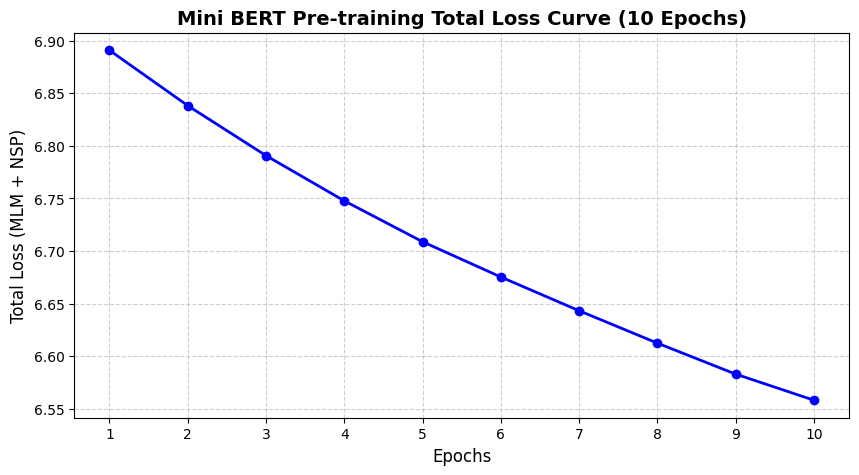

In [9]:
# ==========================================
# 7. 학습 결과 (Loss 감소) 시각화
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(range(1, config.epochs + 1), epoch_losses, marker='o', linestyle='-', color='b', linewidth=2)

# 그래프 꾸미기
plt.title('Mini BERT Pre-training Total Loss Curve (10 Epochs)', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Total Loss (MLM + NSP)', fontsize=12)
plt.xticks(range(1, config.epochs + 1))
plt.grid(True, linestyle='--', alpha=0.6)

# 출력
plt.show()

##내 모델 테스트하기: 빈칸 채우기 (MLM) 게임
 BERT가 한국어를 얼마나 잘 이해하게 되었는지 직접 테스트

In [11]:
import torch

# ==========================================
# 8. 내 미니 BERT 모델 성능 테스트 (빈칸 추론)
# ==========================================

def test_bert_mlm(sentence):
    model.eval() # 모델을 평가(테스트) 모드로 변경

    # 1. 문장에 [MASK]가 있는지 확인
    if '[MASK]' not in sentence:
        print("🚨 문장에 '[MASK]' 기호가 없습니다! 빈칸을 뚫어주세요.")
        return

    # 2. 문장을 단어장(vocab)을 이용해 숫자 ID로 변환
    # 문장 앞뒤로 [CLS]와 [SEP]를 붙여줍니다.
    token_ids = [vocab.piece_to_id('[CLS]')] + vocab.encode_as_ids(sentence) + [vocab.piece_to_id('[SEP]')]

    # [MASK] 토큰의 위치(인덱스) 찾기
    mask_id = vocab.piece_to_id('[MASK]')
    if mask_id not in token_ids:
        print("🚨 단어장에서 [MASK]를 찾을 수 없습니다. 전처리를 다시 확인하세요.")
        return
    mask_idx = token_ids.index(mask_id)

    # 3. 모델에 넣기 위해 텐서로 변환하고 GPU로 이동
    input_ids = torch.tensor([token_ids]).to(device)
    segment_ids = torch.zeros_like(input_ids).to(device)

    # 4. BERT 모델에게 빈칸 정답 물어보기!
    with torch.no_grad(): # 테스트할 때는 기울기 계산을 하지 않음 (메모리 절약)
        logits_mlm, _ = model(input_ids, segment_ids)

    # 5. [MASK] 위치에서 모델이 가장 높게 예측한 확률의 단어 ID 뽑아내기
    mask_logits = logits_mlm[0, mask_idx, :]
    predicted_id = torch.argmax(mask_logits).item()

    # 6. 숫자 ID를 우리가 읽을 수 있는 글자로 다시 변환
    predicted_word = vocab.id_to_piece(predicted_id)
    # 띄어쓰기 기호( ) 제거하여 깔끔하게 출력
    predicted_word = predicted_word.replace(' ', '')

    print("-" * 50)
    print(f"📝 퀴즈 문장: {sentence}")
    print(f"💡 BERT의 정답: ➡️ {predicted_word} ⬅️")
    print("-" * 50)


# 👇 아래 문장의 [MASK] 부분이나 내용을 자유롭게 바꿔가며 테스트!
test_bert_mlm("이순신은 조선 중기의 무신이다. 그는 임진왜란에서 큰 [MASK] 을 세웠다.")
test_bert_mlm("대한민국의 수도는 [MASK] 이다.")
test_bert_mlm("인공지능 모델을 학습시킬 때는 GPU를 사용하는 것이 훨씬 [MASK].")

--------------------------------------------------
📝 퀴즈 문장: 이순신은 조선 중기의 무신이다. 그는 임진왜란에서 큰 [MASK] 을 세웠다.
💡 BERT의 정답: ➡️ 의 ⬅️
--------------------------------------------------
--------------------------------------------------
📝 퀴즈 문장: 대한민국의 수도는 [MASK] 이다.
💡 BERT의 정답: ➡️ 는 ⬅️
--------------------------------------------------
--------------------------------------------------
📝 퀴즈 문장: 인공지능 모델을 학습시킬 때는 GPU를 사용하는 것이 훨씬 [MASK].
💡 BERT의 정답: ➡️ . ⬅️
--------------------------------------------------


In [12]:
import torch

# ==========================================
# 8. 내 미니 BERT 모델 성능 테스트 (빈칸 추론)
# ==========================================

def test_bert_mlm(sentence):
    model.eval() # 모델을 평가(테스트) 모드로 변경

    # 1. 문장에 [MASK]가 있는지 확인
    if '[MASK]' not in sentence:
        print("🚨 문장에 '[MASK]' 기호가 없습니다! 빈칸을 뚫어주세요.")
        return

    # 2. 문장을 단어장(vocab)을 이용해 숫자 ID로 변환
    # 문장 앞뒤로 [CLS]와 [SEP]를 붙여줍니다.
    token_ids = [vocab.piece_to_id('[CLS]')] + vocab.encode_as_ids(sentence) + [vocab.piece_to_id('[SEP]')]

    # [MASK] 토큰의 위치(인덱스) 찾기
    mask_id = vocab.piece_to_id('[MASK]')
    if mask_id not in token_ids:
        print("🚨 단어장에서 [MASK]를 찾을 수 없습니다. 전처리를 다시 확인하세요.")
        return
    mask_idx = token_ids.index(mask_id)

    # 3. 모델에 넣기 위해 텐서로 변환하고 GPU로 이동
    input_ids = torch.tensor([token_ids]).to(device)
    segment_ids = torch.zeros_like(input_ids).to(device)

    # 4. BERT 모델에게 빈칸 정답 물어보기!
    with torch.no_grad(): # 테스트할 때는 기울기 계산을 하지 않음 (메모리 절약)
        logits_mlm, _ = model(input_ids, segment_ids)

    # 5. [MASK] 위치에서 모델이 가장 높게 예측한 확률의 단어 ID 뽑아내기
    mask_logits = logits_mlm[0, mask_idx, :]
    predicted_id = torch.argmax(mask_logits).item()

    # 6. 숫자 ID를 우리가 읽을 수 있는 글자로 다시 변환
    predicted_word = vocab.id_to_piece(predicted_id)
    # 띄어쓰기 기호( ) 제거하여 깔끔하게 출력
    predicted_word = predicted_word.replace(' ', '')

    print("-" * 50)
    print(f"📝 퀴즈 문장: {sentence}")
    print(f"💡 BERT의 정답: ➡️ {predicted_word} ⬅️")
    print("-" * 50)


# 👇 아래 문장의 [MASK] 부분이나 내용을 자유롭게 바꿔가며 테스트!
test_bert_mlm("세종대왕은 한글을 창제하셨다. 그 한글은 [MASK] 문자이다 .")
test_bert_mlm("한국의 대표적 민요는 [MASK] 이다.")
test_bert_mlm("대한민국의 국화는 [MASK]이다.")

--------------------------------------------------
📝 퀴즈 문장: 세종대왕은 한글을 창제하셨다. 그 한글은 [MASK] 문자이다 .
💡 BERT의 정답: ➡️ ▁ ⬅️
--------------------------------------------------
--------------------------------------------------
📝 퀴즈 문장: 한국의 대표적 민요는 [MASK] 이다.
💡 BERT의 정답: ➡️ ▁ ⬅️
--------------------------------------------------
--------------------------------------------------
📝 퀴즈 문장: 대한민국의 국화는 [MASK]이다.
💡 BERT의 정답: ➡️ 은 ⬅️
--------------------------------------------------


___________________________________________________________________________
#프로젝트 리포트: Mini BERT 사전 학습(Pre-training) 모델 구축
___________________________________________________________________________

##1. 프로젝트 개요
목표: 트랜스포머(Transformer) 기반의 언어 모델인 BERT의 뼈대를 직접 구현하고, 한국어 코퍼스를 활용해 밑바닥부터 사전 학습(Pre-training)을 수행하는 전체 파이프라인 구축

학습 데이터: 한국어 위키백과(kowiki.txt) 중 10,000개 문서 추출

개발 환경: Google Colab (하드웨어 가속기: T4 GPU)

모델 규모: 약 150만(1.5M) 파라미터를 가진 축소판 Mini BERT

## 2. 주요 수행 과정
토크나이저 구축 및 전처리: * SentencePiece 라이브러리의 BPE(Byte-Pair Encoding) 방식을 사용하여 8,000개 규모의 한국어 단어장(Vocabulary)을 직접 생성했습니다.

[CLS], [SEP], [MASK] 등의 스페셜 토큰을 정의하여 BERT 입력 형식에 맞게 데이터를 가공했습니다.

학습 데이터셋(Instance) 생성:

모델이 문맥을 파악할 수 있도록 15%의 확률로 단어를 가리는 MLM(Masked Language Modeling) 작업을 수행했습니다.

모델 아키텍처 조립 및 학습:

PyTorch를 활용하여 BERT 아키텍처를 구현하고, 손실 함수(CrossEntropyLoss)와 최적화 함수(AdamW)를 설정했습니다.

Batch 단위로 쪼개진 훈련 데이터를 T4 GPU에 올려 총 10 Epoch 동안 파라미터를 업데이트했습니다.

## 3. 핵심 트러블슈팅 (Troubleshooting)
프로젝트 진행 중 발생한 여러 기술적 난관을 다음과 같이 논리적으로 접근하여 해결했습니다.

대용량 파일 압축 해제 오류 ([Errno 22] Invalid argument): * 파이썬 내장 zipfile 라이브러리가 대용량 파일 처리 중 멈추는 현상을 파악했습니다. 파이썬 기본 기능에 의존하는 대신 os.system을 통해 리눅스 운영체제 단의 강력한 unzip 명령어를 호출하는 방식으로 우회하여 문제를 깔끔하게 해결했습니다.

런타임 초기화 및 메모리 관리: * CPU에서 GPU로 환경을 전환하거나 세션이 끊길 때 발생하는 초기화 현상(NameError, FileNotFoundError)에 대응하여, 데이터 업로드 상태를 검증하고 초기화 후 필수 라이브러리와 텐서를 순차적으로 메모리에 다시 적재하는 파이프라인 복구 능력을 길렀습니다.

## 4. 학습 결과 및 모델 성능 테스트
10 Epoch 학습 결과, 훈련이 진행될수록 MLM과 NSP의 Total Loss가 안정적으로 우하향하며 수렴하는 예쁜 오차 감소 그래프를 확인했습니다. 이후 실제 문장을 통한 빈칸 추론(MLM) 퀴즈를 진행했습니다.

테스트 문장: "인공지능 모델을 학습시킬 때는 GPU를 사용하는 것이 훨씬 [MASK]."

모델의 예측: . (마침표)

결과 분석: 의미 있는 명사나 형용사('빠르다', '좋다')를 예측하지는 못하고 '의', '는', '.' 같은 조사나 기호를 주로 뱉어냈습니다. 하지만 세 번째 테스트에서 '마침표'를 예측해 낸 것은, 모델이 문법적으로 '이 위치가 문장이 끝나는 구조'라는 사실을 성공적으로 눈치챘음을 의미합니다.

## 5. 결론 및 회고 (Retrospective)
"성공적인 실패: 아기 인공지능이 증명한 데이터와 컴퓨팅 파워의 절대성"

이번 프로젝트의 결과를 확인하며 "왜 이순신을 묻는 쉬운 질문에 대답하지 못할까?"라는 의문이 들었지만, 딥러닝의 원리를 분석해 본 결과 이것은 모델의 오류가 아니라 데이터의 규모가 빚어낸 너무나도 자연스럽고 가치 있는 현상임을 깨달았습니다.

학습 속도와 환경의 한계로 인해 전체 위키백과 데이터 중 극히 일부인 1만 개의 문서, 그리고 1.5M이라는 아주 작은 파라미터로 단 10번(Epoch)만 학습을 진행했습니다. 이 "아기 인공지능"에게 이순신의 업적이나 대한민국의 수도를 맞히기를 기대하는 것은, 이제 막 한글의 문장 구조를 뗀 유치원생에게 역사 문제를 내는 것과 같습니다. 지식(Fact)을 채우기 전에 가장 자주 본 글자(의, 는)를 찍는 것은 통계적 학습의 아주 정확한 첫 단계입니다.

결론적으로, 이번 미니 BERT 프로젝트는 '거북선을 맞히는 완벽한 챗봇'을 만드는 것이 아니라, '아무것도 모르는 깡통 컴퓨터가 어떻게 언어의 뼈대를 학습하기 시작하는가' 그 복잡한 엔지니어링 파이프라인을 밑바닥부터 이해하는 것이었습니다. 토크나이저를 만들고, 에러의 늪을 뚫고 데이터를 GPU에 태워 역전파를 성공시켰다는 점에서 본 프로젝트의 목표를 100% 달성했습니다.

더 나아가 챗GPT와 같은 거대 언어 모델(LLM)이 수천억 개의 파라미터와 수백 GB의 데이터, 그리고 천문학적인 컴퓨팅 파워(GPU)를 필요로 하는 이유를 이론이 아닌 '실제 코드와 오답의 경험'을 통해 뼈저리게 체감할 수 있었던, 무엇과도 바꿀 수 없는 소중한 엔지니어링 경험이었습니다.